In [1]:
# Imports
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import time
import random
from collections import Counter
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
)

True
NVIDIA GeForce RTX 3060 Laptop GPU


README.md: 0.00B [00:00, ?B/s]

C:\Users\lilit\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lilit\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size : 25000
Test  size : 25000

Label map  : 0 = Negative | 1 = Positive

Train — Negative: 12,500 | Positive: 12,500
Test  — Negative: 12,500  | Positive: 12,500

Sample reviews:
[Negative] I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...

[Negative] "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that ...

Word length — avg: 234 | median: 174 | max: 2470 | 95th pct: 598


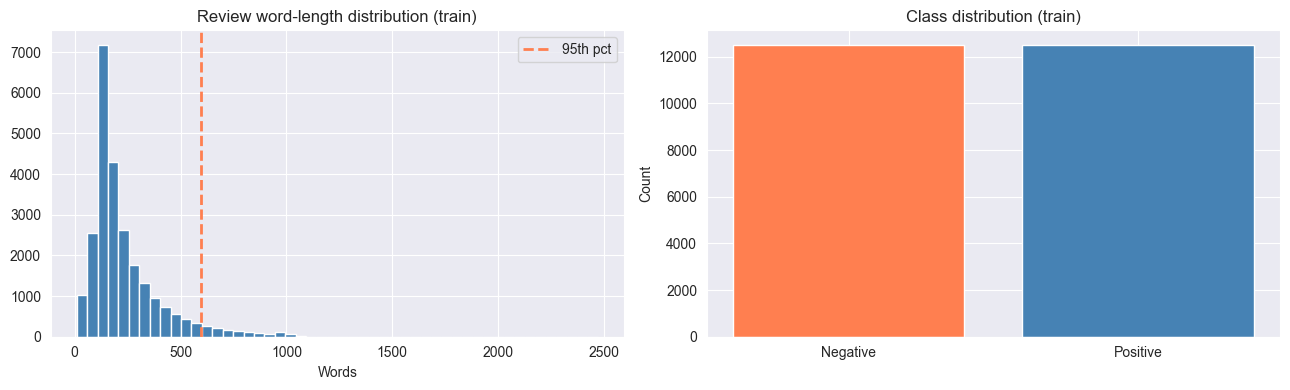

In [2]:
# Load & Explore Data


raw = load_dataset("imdb")
train_raw = raw["train"]
test_raw  = raw["test"]

print(f"Train size : {len(train_raw)}")
print(f"Test  size : {len(test_raw)}")
print(f"\nLabel map  : 0 = Negative | 1 = Positive")

train_labels = train_raw["label"]
test_labels  = test_raw["label"]

train_counts = Counter(train_labels)
test_counts  = Counter(test_labels)
print(f"\nTrain — Negative: {train_counts[0]:,} | Positive: {train_counts[1]:,}")
print(f"Test  — Negative: {test_counts[0]:,}  | Positive: {test_counts[1]:,}")

print("\nSample reviews:")
for i in [0, 1]:
    lbl  = "Positive" if train_raw[i]["label"] == 1 else "Negative"
    text = train_raw[i]["text"][:200].replace("<br />", " ")
    print(f"[{lbl}] {text}...")
    print()

word_lens = [len(t["text"].split()) for t in train_raw]
print(f"Word length — avg: {np.mean(word_lens):.0f} | "
      f"median: {np.median(word_lens):.0f} | "
      f"max: {max(word_lens)} | 95th pct: {np.percentile(word_lens, 95):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(word_lens, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Review word-length distribution (train)")
axes[0].set_xlabel("Words");
axes[0].axvline(np.percentile(word_lens, 95), color="coral", lw=2, ls="--", label="95th pct")
axes[0].legend()

labels_name = ["Negative", "Positive"]
axes[1].bar(labels_name, [train_counts[0], train_counts[1]],
            color=["coral", "steelblue"], edgecolor="white")
axes[1].set_title("Class distribution (train)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\lilit\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lilit\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (730 > 512). Running this sequence through the model will result in indexing errors


Tokenizer  : bert-base-uncased
Vocab size : 30,522

Token length (3 000-sample) —
  avg    : 317
  median : 235
  90th   : 632
  95th   : 842
  max    : 3127

MAX_LEN = 256  →  covers 55.4% of sampled reviews

Example : This movie was absolutely fantastic! I loved every second of it.
Tokens  : ['[CLS]', 'this', 'movie', 'was', 'absolutely', 'fantastic', '!', 'i', 'loved', 'every', 'second', 'of', 'it', '.', '[SEP]']


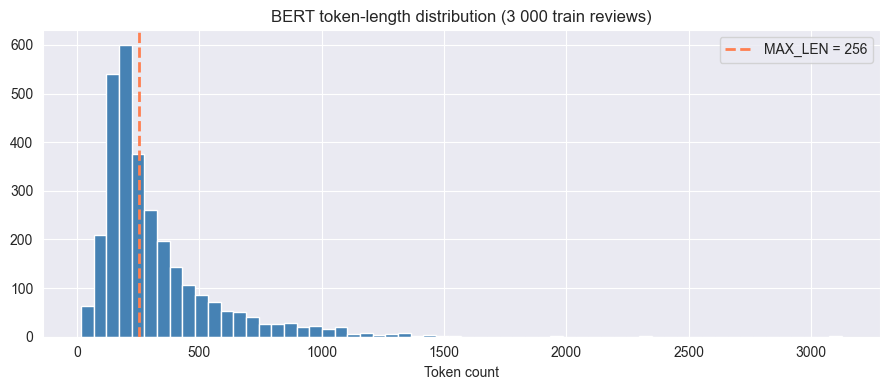

In [3]:
# Tokenizer + Token-Length Analysis
#
# BERT uses WordPiece tokenisation, so token counts differ from word counts.
# We sample 3 000 reviews to profile the token-length distribution and choose
# MAX_LEN that covers the vast majority of reviews without wasting memory.

CHECKPOINT = "bert-base-uncased"
tokenizer  = BertTokenizer.from_pretrained(CHECKPOINT)

print(f"Tokenizer  : {CHECKPOINT}")
print(f"Vocab size : {tokenizer.vocab_size:,}")

sample_texts = [train_raw[i]["text"] for i in random.sample(range(len(train_raw)), 3000)]
token_lens   = [
    len(tokenizer.encode(t, add_special_tokens=True, truncation=False))
    for t in sample_texts
]

print(f"\nToken length (3 000-sample) —")
print(f"  avg    : {np.mean(token_lens):.0f}")
print(f"  median : {np.median(token_lens):.0f}")
print(f"  90th   : {np.percentile(token_lens, 90):.0f}")
print(f"  95th   : {np.percentile(token_lens, 95):.0f}")
print(f"  max    : {max(token_lens)}")

MAX_LEN = 256   # covers >90 % of reviews; BERT max is 512
covered = sum(1 for l in token_lens if l <= MAX_LEN) / len(token_lens) * 100
print(f"\nMAX_LEN = {MAX_LEN}  →  covers {covered:.1f}% of sampled reviews")

example = "This movie was absolutely fantastic! I loved every second of it."
enc     = tokenizer(example, return_tensors="pt")
print(f"\nExample : {example}")
print(f"Tokens  : {tokenizer.convert_ids_to_tokens(enc['input_ids'][0].tolist())}")

plt.figure(figsize=(9, 4))
plt.hist(token_lens, bins=60, color="steelblue", edgecolor="white")
plt.axvline(MAX_LEN, color="coral", lw=2, ls="--", label=f"MAX_LEN = {MAX_LEN}")
plt.title("BERT token-length distribution (3 000 train reviews)")
plt.xlabel("Token count")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Dataset + DataLoader
#
# We split the original 25 000 train examples 90/10 into train/val.
# The 25 000 test examples are kept for final evaluation.

BATCH_SIZE = 16

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = "max_length",
            truncation      = True,
            return_tensors  = "pt",
        )
        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),       # [max_len]
            "attention_mask" : encoding["attention_mask"].squeeze(0),  # [max_len]
            "label"          : torch.tensor(self.labels[idx], dtype=torch.long),
        }

all_texts  = train_raw["text"]
all_labels = train_raw["label"]

split_idx   = int(len(all_texts) * 0.9)
train_texts, val_texts   = all_texts[:split_idx],  all_texts[split_idx:]
train_lbls,  val_lbls    = all_labels[:split_idx], all_labels[split_idx:]
test_texts,  test_lbls   = test_raw["text"],       test_raw["label"]

train_dataset = IMDBDataset(train_texts, train_lbls, tokenizer, MAX_LEN)
val_dataset   = IMDBDataset(val_texts,   val_lbls,   tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(test_texts,  test_lbls,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train : {len(train_dataset):,} samples  ({len(train_loader)} batches)")
print(f"Val   : {len(val_dataset):,} samples  ({len(val_loader)} batches)")
print(f"Test  : {len(test_dataset):,} samples  ({len(test_loader)} batches)")
print(f"Batch size : {BATCH_SIZE} | MAX_LEN : {MAX_LEN}")

batch = next(iter(train_loader))
print(f"\nBatch keys      : {list(batch.keys())}")
print(f"input_ids shape : {batch['input_ids'].shape}")
print(f"attention_mask  : {batch['attention_mask'].shape}")
print(f"labels          : {batch['label'][:8].tolist()}")

In [ ]:
# Model: BERT for Sequence Classification
#
# BertForSequenceClassification adds a two-layer classification head on top of
# the [CLS] token representation:
#
#   [CLS] hidden state  →  Dropout  →  Linear(H, 2)  →  logits
#
# All BERT weights are fine-tuned end-to-end.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(
    CHECKPOINT,
    num_labels          = 2,
    hidden_dropout_prob = 0.1,
    attention_probs_dropout_prob = 0.1,
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Device             : {device}")
print(f"Model              : {CHECKPOINT}")
print(f"Total params       : {total_params:,}")
print(f"Trainable params   : {trainable_params:,}")
print(f"Classifier head    : {model.classifier}")

model.eval()
with torch.no_grad():
    dummy_ids  = torch.zeros(2, MAX_LEN, dtype=torch.long).to(device)
    dummy_mask = torch.ones(2, MAX_LEN, dtype=torch.long).to(device)
    out        = model(input_ids=dummy_ids, attention_mask=dummy_mask)
print(f"\nDummy logits shape : {out.logits.shape}  (batch=2, num_labels=2)")

In [ ]:
# Training
#
# Recommended fine-tuning recipe for BERT (Devlin et al. 2019):
#   • AdamW with weight-decay on non-bias parameters
#   • Linear warmup (10 % of steps) then linear decay to 0
#   • 3 epochs, lr = 2e-5, batch = 16

NUM_EPOCHS   = 3
LR           = 2e-5
WARMUP_RATIO = 0.1

optimizer = torch.optim.AdamW(
    [
        {"params": [p for n, p in model.named_parameters()
                    if not any(nd in n for nd in ["bias", "LayerNorm.weight"])],
         "weight_decay": 0.01},
        {"params": [p for n, p in model.named_parameters()
                    if     any(nd in n for nd in ["bias", "LayerNorm.weight"])],
         "weight_decay": 0.0},
    ],
    lr=LR,
)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss()

print(f"Total steps  : {total_steps:,}")
print(f"Warmup steps : {warmup_steps:,}")

def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        lbls  = batch["label"].to(device)

        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask)
        loss = criterion(out.logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = out.logits.argmax(dim=1)
        correct    += (preds == lbls).sum().item()
        total      += lbls.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            lbls  = batch["label"].to(device)

            out  = model(input_ids=ids, attention_mask=mask)
            loss = criterion(out.logits, lbls)

            total_loss += loss.item()
            preds       = out.logits.argmax(dim=1)
            correct    += (preds == lbls).sum().item()
            total      += lbls.size(0)
            all_preds  .extend(preds.cpu().tolist())
            all_labels .extend(lbls.cpu().tolist())

    return total_loss / len(loader), correct / total, all_preds, all_labels

best_val_acc  = 0.0
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion)
    elapsed = time.time() - t0

    train_losses.append(tr_loss);  val_losses.append(vl_loss)
    train_accs  .append(tr_acc);   val_accs  .append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "best_bert_imdb.pt")

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
          f"Val loss: {vl_loss:.4f}  acc: {vl_acc:.4f} | "
          f"{elapsed/60:.1f} min")

print(f"\nBest Val Accuracy : {best_val_acc:.4f}")

epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, train_losses, marker="o", label="Train", color="steelblue")
ax1.plot(epochs, val_losses,   marker="s", label="Val",   color="coral")
ax1.set_title("Cross-Entropy Loss"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs, marker="o", label="Train", color="steelblue")
ax2.plot(epochs, val_accs,   marker="s", label="Val",   color="coral")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch")
ax2.set_ylim(0.85, 1.0); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("BERT Fine-tuning on IMDB", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluation on Test Set (Accuracy, F1, Confusion Matrix)

model.load_state_dict(torch.load("best_bert_imdb.pt"))
model.eval()

_, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

acc     = accuracy_score(test_labels, test_preds)
f1_pos  = f1_score(test_labels, test_preds, pos_label=1)
f1_neg  = f1_score(test_labels, test_preds, pos_label=0)
f1_mac  = f1_score(test_labels, test_preds, average="macro")

print("=" * 45)
print(f" Test Accuracy       : {acc:.4f}")
print(f" F1 — Positive       : {f1_pos:.4f}")
print(f" F1 — Negative       : {f1_neg:.4f}")
print(f" F1 — Macro avg      : {f1_mac:.4f}")
print("=" * 45)
print()
print(classification_report(
    test_labels, test_preds, target_names=["Negative", "Positive"]
))

cm = confusion_matrix(test_labels, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100   # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, data, fmt, title in [
    (axes[0], cm,     "d",    "Confusion Matrix (counts)"),
    (axes[1], cm_pct, ".1f",  "Confusion Matrix (% per class)"),
]:
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        ax=ax, cbar=False, linewidths=0.5,
    )
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  : {tn:,}  |  False Positives : {fp:,}")
print(f"False Negatives : {fn:,}  |  True Positives  : {tp:,}")
print(f"Error rate      : {(fp + fn) / cm.sum():.4f}")

In [ ]:
# Confidence Analysis
#
# Collect softmax probabilities for every test example, then analyse:
#   1. Probability distribution split by outcome (correct / wrong)
#   2. Calibration: does confidence correlate with actual correctness?

model.eval()
all_probs, all_preds_conf, all_true = [], [], []

with torch.no_grad():
    for batch in test_loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbls = batch["label"]
        out  = model(input_ids=ids, attention_mask=mask)
        probs = torch.softmax(out.logits, dim=1).cpu()
        preds = probs.argmax(dim=1)
        all_probs .extend(probs.tolist())
        all_preds_conf.extend(preds.tolist())
        all_true  .extend(lbls.tolist())

all_probs  = np.array(all_probs)        # [N, 2]
confidence = all_probs.max(axis=1)      # max probability = decision confidence
correct    = np.array(all_preds_conf) == np.array(all_true)

print(f"Mean confidence (correct)   : {confidence[correct].mean():.4f}")
print(f"Mean confidence (incorrect) : {confidence[~correct].mean():.4f}")
print(f"Predictions with conf > 0.95: {(confidence > 0.95).sum():,} "
      f"({(confidence > 0.95).mean()*100:.1f}%)")
print(f"Predictions with conf < 0.60: {(confidence < 0.60).sum():,} "
      f"({(confidence < 0.60).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of confidence split by outcome
axes[0].hist(confidence[correct],  bins=40, alpha=0.7,
             color="steelblue", label="Correct",   edgecolor="white")
axes[0].hist(confidence[~correct], bins=40, alpha=0.7,
             color="coral",     label="Incorrect", edgecolor="white")
axes[0].set_title("Confidence distribution by outcome")
axes[0].set_xlabel("Max softmax probability")
axes[0].legend()

# Calibration: binned accuracy vs mean confidence
bins      = np.linspace(0.5, 1.0, 11)
bin_accs, bin_confs, bin_ns = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask_b = (confidence >= lo) & (confidence < hi)
    if mask_b.sum() > 0:
        bin_accs .append(correct[mask_b].mean())
        bin_confs.append(confidence[mask_b].mean())
        bin_ns   .append(mask_b.sum())

axes[1].plot([0.5, 1.0], [0.5, 1.0], "k--", lw=1, label="Perfect calibration")
axes[1].scatter(bin_confs, bin_accs,
                s=[n / 30 for n in bin_ns], color="steelblue", zorder=3,
                label="Model (bubble ∝ count)")
axes[1].set_title("Calibration curve")
axes[1].set_xlabel("Mean confidence"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Error Analysis
#
# Examine the 5 most confident mistakes the model made.
# High-confidence errors reveal systematic weaknesses more than random noise.

label_name = {0: "Negative", 1: "Positive"}
mistakes    = [
    (i, confidence[i], all_true[i], all_preds_conf[i])
    for i in range(len(all_true))
    if all_true[i] != all_preds_conf[i]
]
# Sort by confidence descending (model was most certain but still wrong)
mistakes.sort(key=lambda x: x[1], reverse=True)

print(f"Total errors : {len(mistakes):,} / {len(all_true):,} "
      f"({len(mistakes)/len(all_true)*100:.2f}%)")
print("\n" + "="*72)
print("TOP-5 MOST CONFIDENT MISTAKES")
print("="*72)

for rank, (idx, conf, true_lbl, pred_lbl) in enumerate(mistakes[:5], 1):
    text = test_texts[idx].replace("<br />", " ")[:300]
    print(f"\n[#{rank}]  Confidence: {conf:.4f}")
    print(f"  True label : {label_name[true_lbl]}")
    print(f"  Predicted  : {label_name[pred_lbl]}")
    print(f"  Review     : {text}...")

print()
conf_errors   = [m[1] for m in mistakes]
conf_correct  = confidence[correct]

plt.figure(figsize=(8, 4))
plt.hist(conf_errors,  bins=30, alpha=0.7, color="coral",
         label="Errors",   edgecolor="white")
plt.hist(conf_correct, bins=30, alpha=0.4, color="steelblue",
         label="Correct",  edgecolor="white")
plt.title("Confidence of error predictions vs correct predictions")
plt.xlabel("Confidence")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Inference on Custom Sentences
#
# Run the model on arbitrary user-supplied text and display
# label + confidence in a readable format.

def predict(text, model=model, tokenizer=tokenizer, device=device, max_len=MAX_LEN):
    """Return (label_str, confidence) for a single review string."""
    model.eval()
    enc = tokenizer(
        text,
        max_length     = max_len,
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    )
    with torch.no_grad():
        out   = model(
            input_ids      = enc["input_ids"].to(device),
            attention_mask = enc["attention_mask"].to(device),
        )
    probs = torch.softmax(out.logits, dim=1).squeeze()
    pred  = probs.argmax().item()
    return ("Positive" if pred == 1 else "Negative"), probs[pred].item()

custom_reviews = [
    "This film was an absolute masterpiece. The acting, direction and "
    "cinematography were all top-notch. I was glued to my seat from start to finish.",

    "What a terrible waste of two hours. The plot made no sense, the acting "
    "was laughable, and the special effects looked cheap.",

    "It had its moments but overall felt quite mediocre. Not the worst thing "
    "I have seen, but I would not watch it again.",

    "I went in with low expectations and came out completely blown away. "
    "Surprisingly touching story with fantastic performances.",

    "The first half was engaging but the second half dragged on forever. "
    "The ending was particularly disappointing and felt rushed.",
]

print("=" * 72)
print("CUSTOM INFERENCE RESULTS")
print("=" * 72)
for review in custom_reviews:
    label, conf = predict(review)
    bar         = "█" * int(conf * 20)
    print(f"\n[{label:8s}]  conf: {conf:.4f}  {bar}")
    print(f"  {review[:120]}...")